# 🏢 Microsoft Supply Chain Network Optimization — Graph Algorithms

**Session 2 | Industrial Use Case 1 | DSA & ML for Business**

---

### Business Context
- Microsoft's hardware supply chain: **Surface, Xbox, Azure servers, HoloLens**
- Components move between **30+ factories & 60+ data centers** globally
- COVID-19 exposed fragility: **64% of companies** faced supply disruption in 2021
- Goal: minimize cost while maintaining delivery SLAs and managing risk

### What You'll Learn
1. Build a **multi-layer supply chain graph** (Supplier → Factory → Warehouse → Data Center)
2. Compute **shortest paths** (Dijkstra) optimizing for cost and time
3. Calculate **Minimum Spanning Tree** for minimum-cost network
4. Use **betweenness centrality** to identify critical vulnerability nodes
5. **Simulate node failure** and quantify disruption impact

## Step 1: Import Libraries & Load Dataset

In [13]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load dataset
df = pd.read_csv("../datasets/microsoft_supply_chain.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# ---------- Why classify node types? ----------
# A supply chain has distinct LAYERS: Suppliers → Factories → Warehouses → Data Centers
# Classifying nodes helps us understand the structure and visualize the flow direction.
# This layered structure is what makes the graph a "multi-layer" network.
def get_node_type(name):
    if 'Supplier' in name: return 'Supplier'
    elif 'Factory' in name: return 'Factory'
    elif 'Warehouse' in name: return 'Warehouse'
    elif 'DC' in name: return 'Data Center'
    return 'Unknown'

all_nodes = set(df['source']) | set(df['destination'])
node_types = {n: get_node_type(n) for n in all_nodes}

print(f"\nNode types:")
for t in ['Supplier', 'Factory', 'Warehouse', 'Data Center']:
    count = sum(1 for v in node_types.values() if v == t)
    print(f"  {t}: {count}")
print(f"\nTotal edges: {len(df)}")
df.head(10)

Dataset shape: (68, 6)
Columns: ['source', 'destination', 'cost', 'delivery_time', 'risk_score', 'capacity']

Node types:
  Supplier: 6
  Factory: 5
  Warehouse: 5
  Data Center: 8

Total edges: 68


,source,destination,cost,delivery_time,risk_score,capacity
0,Supplier_Taiwan_TSMC,Factory_China_Shanghai,179.51,18.47,0.12,865
1,Supplier_Taiwan_TSMC,Factory_Mexico_Guadalajara,100.69,12.08,0.64,4193
2,Supplier_Taiwan_TSMC,Factory_Czech_Prague,353.37,4.49,0.43,4784
3,Supplier_Korea_Samsung,Factory_Ireland,85.61,3.43,0.11,3721
4,Supplier_Korea_Samsung,Factory_Mexico_Guadalajara,63.46,17.53,0.25,774
5,Supplier_Korea_Samsung,Factory_Czech_Prague,702.05,11.96,0.37,9236
6,Supplier_Japan_Sony,Factory_Ireland,430.62,7.91,0.19,7927
7,Supplier_Japan_Sony,Factory_China_Shanghai,788.40,2.81,0.09,7033
8,Supplier_Japan_Sony,Factory_Mexico_Guadalajara,250.72,9.96,0.39,4462
9,Supplier_Japan_Sony,Factory_Czech_Prague,284.34,13.34,0.12,3735


## Step 2: Build the Supply Chain Graph

Supply Chain Graph:
  Nodes: 24
  Edges: 68
  Is DAG: True


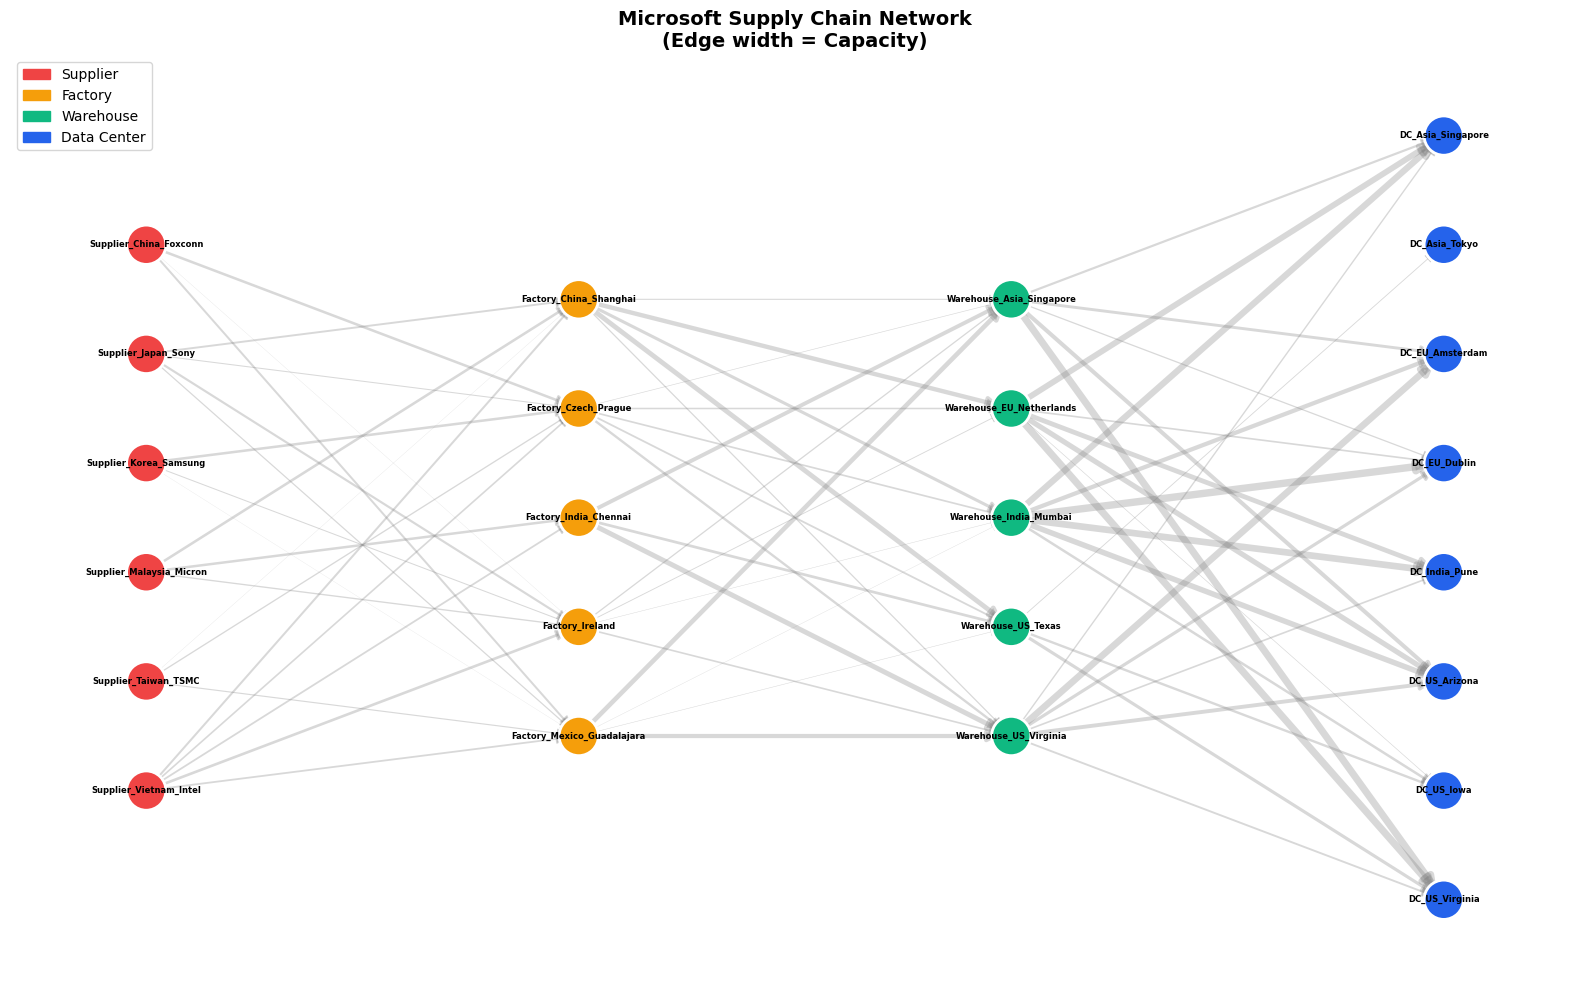

In [14]:
# ---------- Why a Directed Weighted Graph? ----------
# Direction matters: goods flow one way (Supplier → Factory → Warehouse → DC).
# Weights (cost, time, risk) let us optimize routes — e.g., find the cheapest path.
# Without weights, all edges look equal; with weights, Dijkstra & MST become meaningful.

G = nx.DiGraph()

for _, row in df.iterrows():
    G.add_edge(row['source'], row['destination'],
               cost=row['cost'],            # shipping cost ($) — used by Dijkstra for cheapest route
               delivery_time=row['delivery_time'],  # days — used for time-based optimization
               risk_score=row['risk_score'],         # 0-1 probability of disruption on this link
               capacity=row['capacity'])             # max units/month — shown as edge width

# Set node attributes
nx.set_node_attributes(G, node_types, 'type')

print(f"Supply Chain Graph:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Is DAG: {nx.is_directed_acyclic_graph(G)}")

# ---------- Visualization ----------
# We arrange nodes in columns by layer (Supplier → Factory → Warehouse → DC)
# so the left-to-right flow mirrors the real supply chain direction.
fig, ax = plt.subplots(figsize=(16, 10))

layer_order = {'Supplier': 0, 'Factory': 1, 'Warehouse': 2, 'Data Center': 3}
pos = {}
for layer_name, layer_x in layer_order.items():
    nodes_in_layer = [n for n, t in node_types.items() if t == layer_name]
    for i, node in enumerate(sorted(nodes_in_layer)):
        pos[node] = (layer_x * 3, -(i - len(nodes_in_layer)/2) * 1.2)

type_colors = {'Supplier': '#EF4444', 'Factory': '#F59E0B', 'Warehouse': '#10B981', 'Data Center': '#2563EB'}
node_colors = [type_colors[node_types[n]] for n in G.nodes()]

edge_widths = [G[u][v]['capacity'] / 5000 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, alpha=0.3, width=edge_widths, edge_color='gray',
                       arrows=True, arrowsize=15, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800,
                       edgecolors='white', linewidths=2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=6, font_weight='bold', ax=ax)

patches = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
ax.legend(handles=patches, loc='upper left', fontsize=10)
ax.set_title('Microsoft Supply Chain Network\n(Edge width = Capacity)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## Step 3: Shortest Path Analysis (Dijkstra) — Optimizing for Cost & Time

In [15]:
# ---------- What is Dijkstra's Algorithm and why use it here? ----------
# Dijkstra finds the CHEAPEST (or fastest) path between two nodes in a weighted graph.
# In a supply chain, there are many possible routes from a Supplier to a Data Center.
# Dijkstra picks the one with the lowest total cost — exactly what a logistics team needs.
#
# Real-world analogy: Google Maps finds the fastest driving route by treating roads as
# weighted edges (weight = travel time). We do the same but with shipping cost as weight.

suppliers = [n for n, t in node_types.items() if t == 'Supplier']
datacenters = [n for n, t in node_types.items() if t == 'Data Center']

print("=== Shortest Paths: Supplier → Data Center (by Cost) ===\n")
all_paths = []
for supplier in sorted(suppliers):
    for dc in sorted(datacenters):
        try:
            path = nx.dijkstra_path(G, supplier, dc, weight='cost')
            cost = nx.dijkstra_path_length(G, supplier, dc, weight='cost')
            # Along the cheapest path, also compute delivery time and worst-case risk
            total_time = sum(G[path[i]][path[i+1]]['delivery_time'] for i in range(len(path)-1))
            total_risk = max(G[path[i]][path[i+1]]['risk_score'] for i in range(len(path)-1))
            all_paths.append({
                'source': supplier, 'dest': dc,
                'path': ' → '.join([n.split('_')[-1] for n in path]),
                'total_cost': round(cost, 2),
                'total_time': round(total_time, 1),
                'max_risk': round(total_risk, 2),
                'hops': len(path) - 1
            })
        except nx.NetworkXNoPath:
            pass

paths_df = pd.DataFrame(all_paths)
print(f"Total reachable routes: {len(paths_df)}")
print(f"\n--- Cheapest 10 Routes ---")
print(paths_df.nsmallest(10, 'total_cost')[
    ['source', 'dest', 'total_cost', 'total_time', 'max_risk', 'hops']].to_string(index=False))

=== Shortest Paths: Supplier → Data Center (by Cost) ===

Total reachable routes: 48

--- Cheapest 10 Routes ---
                source              dest  total_cost  total_time  max_risk  hops
Supplier_Korea_Samsung        DC_US_Iowa      143.92        29.3      0.42     3
  Supplier_Taiwan_TSMC        DC_US_Iowa      181.15        23.8      0.64     3
Supplier_Korea_Samsung    DC_US_Virginia      182.02        32.0      0.42     3
Supplier_Korea_Samsung   DC_EU_Amsterdam      186.99        10.5      0.33     3
  Supplier_Taiwan_TSMC    DC_US_Virginia      219.25        26.6      0.64     3
  Supplier_Taiwan_TSMC     DC_India_Pune      248.39        24.6      0.38     3
Supplier_Korea_Samsung     DC_US_Arizona      267.57        11.5      0.33     3
  Supplier_Taiwan_TSMC   DC_EU_Amsterdam      273.46        22.9      0.64     3
Supplier_Korea_Samsung DC_Asia_Singapore      297.01        12.1      0.33     3
Supplier_Korea_Samsung     DC_India_Pune      299.71        34.9      0.37   

## Step 4: Minimum Spanning Tree & Centrality Analysis

Minimum Spanning Tree:
  MST edges: 23 (out of 68 total)
  MST total cost: $2,720.24
  Full network cost: $17,856.25
  Cost savings: $15,136.01 (84.8%)

=== Betweenness Centrality: Most Critical Nodes ===
  Factory_Mexico_Guadalajara          | Betweenness: 0.0711 | Type: Factory
  Warehouse_US_Virginia               | Betweenness: 0.0573 | Type: Warehouse
  Warehouse_US_Texas                  | Betweenness: 0.0514 | Type: Warehouse
  Factory_Ireland                     | Betweenness: 0.0415 | Type: Factory
  Warehouse_Asia_Singapore            | Betweenness: 0.0277 | Type: Warehouse
  Warehouse_EU_Netherlands            | Betweenness: 0.0237 | Type: Warehouse
  Factory_Czech_Prague                | Betweenness: 0.0217 | Type: Factory
  Factory_China_Shanghai              | Betweenness: 0.0158 | Type: Factory
  Warehouse_India_Mumbai              | Betweenness: 0.0119 | Type: Warehouse
  Factory_India_Chennai               | Betweenness: 0.0040 | Type: Factory


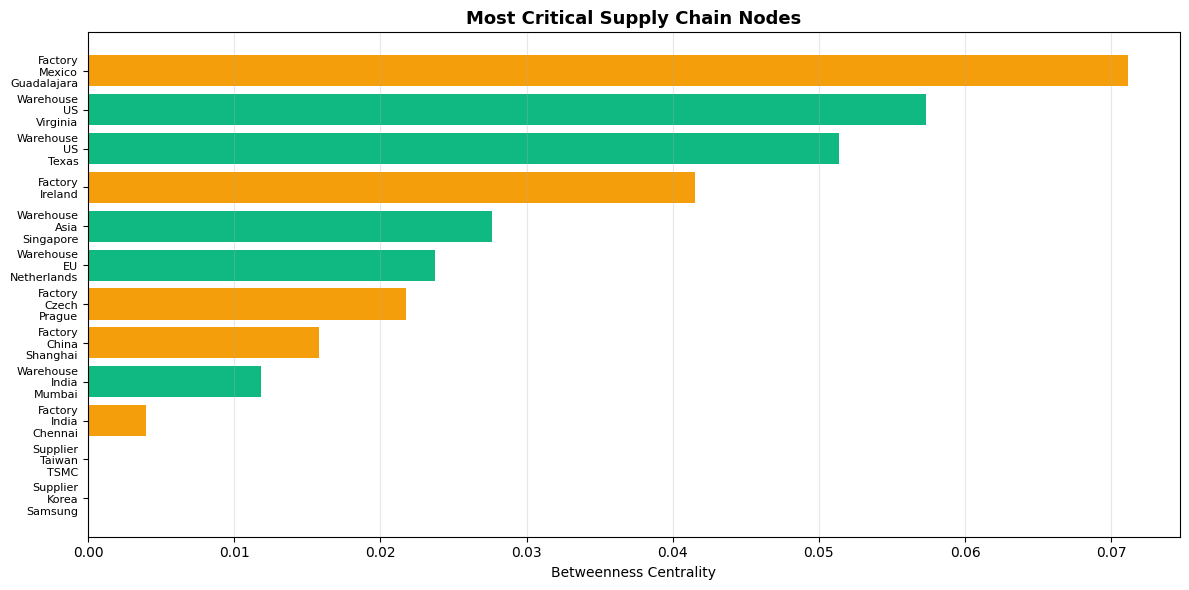

In [16]:
# ---------- What is a Minimum Spanning Tree (MST) and why do we need it? ----------
# MST answers: "What is the CHEAPEST way to keep all nodes connected?"
# It selects the minimum-cost subset of edges that still reaches every node — no cycles.
#
# Business meaning: If Microsoft had to rebuild its supply chain from scratch with the
# lowest possible infrastructure cost, the MST shows exactly which links to keep.
# The difference between the full network cost and the MST cost tells us how much
# we're spending on REDUNDANCY (backup routes) — which is good for resilience but costly.

G_undirected = G.to_undirected()  # MST requires an undirected graph

mst = nx.minimum_spanning_tree(G_undirected, weight='cost')
mst_cost = sum(d['cost'] for _, _, d in mst.edges(data=True))
total_cost = sum(d['cost'] for _, _, d in G_undirected.edges(data=True))
print(f"Minimum Spanning Tree:")
print(f"  MST edges: {mst.number_of_edges()} (out of {G.number_of_edges()} total)")
print(f"  MST total cost: ${mst_cost:,.2f}")
print(f"  Full network cost: ${total_cost:,.2f}")
print(f"  Cost savings: ${total_cost - mst_cost:,.2f} ({(1 - mst_cost/total_cost)*100:.1f}%)")

# ---------- What is Betweenness Centrality and why does it matter? ----------
# Betweenness centrality measures how many shortest paths pass THROUGH a node.
# A node with high betweenness is a "bottleneck" — if it fails, many routes break.
# Think of it as a highway junction: if it shuts down, traffic across the region collapses.
# Identifying these nodes helps Microsoft prioritize where to invest in redundancy.

betweenness = nx.betweenness_centrality(G, weight='cost')
print(f"\n=== Betweenness Centrality: Most Critical Nodes ===")
sorted_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)
for node, bc in sorted_betweenness[:10]:
    print(f"  {node:<35s} | Betweenness: {bc:.4f} | Type: {node_types[node]}")

fig, ax = plt.subplots(figsize=(12, 6))
nodes_sorted = sorted(betweenness.keys(), key=lambda x: betweenness[x], reverse=True)[:12]
colors = [type_colors[node_types[n]] for n in nodes_sorted]
ax.barh(range(len(nodes_sorted)), [betweenness[n] for n in nodes_sorted], color=colors)
ax.set_yticks(range(len(nodes_sorted)))
ax.set_yticklabels([n.replace('_', '\n') for n in nodes_sorted], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Betweenness Centrality')
ax.set_title('Most Critical Supply Chain Nodes', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 5: Node Failure Simulation — Disruption Impact Analysis

What happens when the most critical node goes offline?

In [17]:
# ---------- Why simulate node failure? ----------
# Knowing which nodes are critical (from betweenness) is useful, but HOW BAD is it
# when they actually go down? This simulation removes each critical node one at a time
# and measures: (a) how many routes break entirely, and (b) how much more expensive
# the surviving routes become as traffic reroutes through alternatives.
#
# This is the same "stress test" approach banks use for financial risk — here applied
# to supply chain resilience.

print("=== NODE FAILURE SIMULATION ===\n")

# First, count how many Supplier → DC routes exist in the healthy network (baseline)
baseline_paths = 0
for s in suppliers:
    for dc in datacenters:
        if nx.has_path(G, s, dc):
            baseline_paths += 1

print(f"Baseline reachable routes (Supplier → DC): {baseline_paths}")

critical_nodes = [n for n, _ in sorted_betweenness[:5]]
disruption_results = []

for node in critical_nodes:
    # Remove the node and see what breaks
    G_fail = G.copy()
    G_fail.remove_node(node)
    remaining_paths = 0
    cost_increase_paths = []
    for s in suppliers:
        for dc in datacenters:
            if s == node or dc == node:
                continue
            try:
                new_cost = nx.dijkstra_path_length(G_fail, s, dc, weight='cost')
                try:
                    old_cost = nx.dijkstra_path_length(G, s, dc, weight='cost')
                    cost_increase_paths.append(new_cost - old_cost)  # how much more expensive?
                except: pass
                remaining_paths += 1
            except nx.NetworkXNoPath:
                pass

    path_loss = baseline_paths - remaining_paths
    avg_cost_increase = np.mean(cost_increase_paths) if cost_increase_paths else 0
    disruption_results.append({
        'node': node, 'type': node_types[node],
        'betweenness': betweenness[node],
        'paths_lost': path_loss,
        'pct_loss': path_loss / baseline_paths * 100,
        'avg_cost_increase': avg_cost_increase
    })
    print(f"\n  ❌ Remove: {node}")
    print(f"     Type: {node_types[node]} | Betweenness: {betweenness[node]:.4f}")
    print(f"     Paths lost: {path_loss}/{baseline_paths} ({path_loss/baseline_paths*100:.1f}%)")
    print(f"     Avg cost increase on remaining routes: ${avg_cost_increase:.2f}")

disrupt_df = pd.DataFrame(disruption_results)

=== NODE FAILURE SIMULATION ===

Baseline reachable routes (Supplier → DC): 48

  ❌ Remove: Factory_Mexico_Guadalajara
     Type: Factory | Betweenness: 0.0711
     Paths lost: 0/48 (0.0%)
     Avg cost increase on remaining routes: $79.67

  ❌ Remove: Warehouse_US_Virginia
     Type: Warehouse | Betweenness: 0.0573
     Paths lost: 0/48 (0.0%)
     Avg cost increase on remaining routes: $39.68

  ❌ Remove: Warehouse_US_Texas
     Type: Warehouse | Betweenness: 0.0514
     Paths lost: 6/48 (12.5%)
     Avg cost increase on remaining routes: $63.48

  ❌ Remove: Factory_Ireland
     Type: Factory | Betweenness: 0.0415
     Paths lost: 0/48 (0.0%)
     Avg cost increase on remaining routes: $34.06

  ❌ Remove: Warehouse_Asia_Singapore
     Type: Warehouse | Betweenness: 0.0277
     Paths lost: 0/48 (0.0%)
     Avg cost increase on remaining routes: $9.06


## Step 6: Strategic Analysis & Recommendations

In [18]:
# ---------- Turning graph analysis into business decisions ----------
# This section translates the technical findings into dollar amounts and actionable
# recommendations that a VP of Operations would care about.
# Key idea: the MST tells us the minimum network cost; betweenness + failure simulation
# tell us WHERE to spend extra (redundancy) to protect against disruption.

print("=" * 70)
print("EXECUTIVE BRIEF: Supply Chain Disruption Risk Assessment")
print("=" * 70)

worst_case = disrupt_df.nlargest(1, 'pct_loss').iloc[0]
print(f"\n1. CRITICAL VULNERABILITY:")
print(f"   Node: {worst_case['node']}")
print(f"   Type: {worst_case['type']}")
print(f"   Impact if offline: {worst_case['pct_loss']:.1f}% of routes lost")
print(f"   Avg cost increase on surviving routes: ${worst_case['avg_cost_increase']:.2f}/unit")

# Translate into financial exposure using realistic assumptions
daily_shipments = 10000
avg_margin_per_unit = 150
delayed_pct = worst_case['pct_loss'] / 100
daily_exposure = daily_shipments * delayed_pct * avg_margin_per_unit

print(f"\n2. FINANCIAL EXPOSURE:")
print(f"   Daily shipments affected: {daily_shipments * delayed_pct:,.0f}")
print(f"   Daily revenue at risk: ${daily_exposure:,.0f}")
print(f"   Monthly exposure: ${daily_exposure * 30:,.0f}")
print(f"   Annual exposure: ${daily_exposure * 365:,.0f}")

print(f"\n3. REDUNDANCY RECOMMENDATION:")
print(f"   → Establish backup route bypassing {worst_case['node']}")
print(f"   → Estimated CapEx for redundancy: ${daily_exposure * 30 * 0.2:,.0f}")
print(f"   → Priority: Add secondary warehouse in same region")

# MST insight: how much of the current network cost is "insurance" (redundancy)?
print(f"\n4. MST INSIGHT:")
print(f"   Minimum viable network cost: ${mst_cost:,.2f}")
print(f"   Current redundancy investment: ${total_cost - mst_cost:,.2f}")
print(f"   Redundancy ratio: {(total_cost/mst_cost - 1)*100:.1f}% above minimum")

EXECUTIVE BRIEF: Supply Chain Disruption Risk Assessment

1. CRITICAL VULNERABILITY:
   Node: Warehouse_US_Texas
   Type: Warehouse
   Impact if offline: 12.5% of routes lost
   Avg cost increase on surviving routes: $63.48/unit

2. FINANCIAL EXPOSURE:
   Daily shipments affected: 1,250
   Daily revenue at risk: $187,500
   Monthly exposure: $5,625,000
   Annual exposure: $68,437,500

3. REDUNDANCY RECOMMENDATION:
   → Establish backup route bypassing Warehouse_US_Texas
   → Estimated CapEx for redundancy: $1,125,000
   → Priority: Add secondary warehouse in same region

4. MST INSIGHT:
   Minimum viable network cost: $2,720.24
   Current redundancy investment: $15,136.01
   Redundancy ratio: 556.4% above minimum
